## Imports

In [59]:
# Core libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Machine learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Visualization
import plotly.express as px

# Utilities
import math
from kneed import KneeLocator

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Constants
BASE_PATH = Path("D:/Assignments/Semester-5/Machine-Learning/AFL2")
DATA_PATH = BASE_PATH / "data"
IMAGES_PATH = BASE_PATH / "images"
RANDOM_STATE = 42

# Ensure images directory exists
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

## Data Cleaning and Loading

In [60]:
# Load data
input_file = DATA_PATH / "original_data.csv"
output_file = DATA_PATH / "cleaned_data.csv"

print(f"Loading data from: {input_file}")
df = pd.read_csv(input_file, delimiter=';', encoding='latin1')

print(f"Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Loading data from: D:\Assignments\Semester-5\Machine-Learning\AFL2\data\original_data.csv
Data loaded successfully!
Shape: (10000, 22)

First few rows:


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,"time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,"
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,"1577359415,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,..."
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,"1577017063,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,..."
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1,0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,"1577359410,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,..."
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1,0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,"1576667743,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,..."
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,"1577359401,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,..."


In [61]:
df.describe()

,price,longitude
count,10000.000000,9944.000000
mean,1482.881600,-94.675157
std,1074.952131,15.762033
min,200.000000,-158.022100
25%,945.000000,-101.301700
50%,1267.500000,-93.651600
75%,1695.000000,-82.313000
max,52500.000000,-70.191600


# Data Preprocessing

In [62]:
# Analyze missing values
print("Missing values per column:")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_percent
}).sort_values('Percentage', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

# Fill columns with many missing values
df["amenities"] = df["amenities"].fillna("None")
df["pets_allowed"] = df["pets_allowed"].fillna("Not specified")

# Drop rows with missing values in critical columns (< 1% missing)
rows_to_drop = ["bedrooms", "bathrooms", "cityname", "state", "latitude", "longitude"]
initial_rows = len(df)
df = df.dropna(subset=rows_to_drop)
print(f"\nDropped {initial_rows - len(df)} rows with missing critical values")

# Drop redundant and irrelevant columns
columns_to_drop = [
    "id",            # Unique identifier, not useful for analysis
    "title",         # Unstructured text, not useful for clustering
    "body",          # Unstructured text, not useful for clustering
    "price_display", # Redundant with 'price'
    "address",       # Redundant with coordinates
    "cityname",      # Replaced by latitude/longitude
    "state",         # Replaced by latitude/longitude
    "source",        # Not relevant to apartment characteristics
]

columns_that_exist = [col for col in columns_to_drop if col in df.columns]
if columns_that_exist:
    df = df.drop(columns=columns_that_exist)
    print(f"\nDropped {len(columns_that_exist)} redundant columns: {columns_that_exist}")
else:
    print("\nNo redundant columns to drop.")

Missing values per column:
                                                    Missing Count  Percentage
pets_allowed                                                 4139       41.39
amenities                                                    3548       35.48
address                                                      3285       32.85
cityname                                                       77        0.77
state                                                          77        0.77
longitude                                                      56        0.56
source                                                         46        0.46
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,...             46        0.46
price_display                                                  42        0.42
bathrooms                                                      34        0.34
currency                                                       24        0.24
latitude                             

In [63]:
print(f"New DataFrame shape: {df.shape}")
print("\nRemaining columns:")
print(df.info())

New DataFrame shape: (9837, 14)

Remaining columns:
<class 'pandas.core.frame.DataFrame'>
Index: 9837 entries, 2 to 9999
Data columns (total 14 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   category                                                                    9837 non-null   object 
 1   amenities                                                                   9837 non-null   object 
 2   bathrooms                                                                   9837 non-null   object 
 3   bedrooms                                                                    9837 non-null   object 
 4   currency                                                                    9837 non-null   object 
 5   fee                                                                         9837 non-null   object 
 6   h

In [64]:
# Analyze and transform low-variance columns
low_variance_threshold = 0.99

# Check each potential low-variance column
columns_to_check = ["category", "currency", "fee", "price_type"]
for col in columns_to_check:
    if col in df.columns:
        value_counts = df[col].value_counts()
        print(f"\n{col}:")
        print(value_counts)

# Transform 'has_photo' to binary
if "has_photo" in df.columns:
    if df["has_photo"].dtype == "object":
        print("\nOriginal 'has_photo' values:")
        print(df["has_photo"].value_counts())
        
        # Map to binary: Yes/Thumbnail = 1, No = 0
        df["has_photo"] = df["has_photo"].map({"Yes": 1, "Thumbnail": 1, "No": 0})
        
        print("\nTransformed 'has_photo' to binary:")
        print(df["has_photo"].value_counts().sort_index())
    else:
        print("\n'has_photo' already converted:")
        print(df["has_photo"].value_counts().sort_index())


category:
category
housing/rent/apartment     9834
housing/rent/home             2
housing/rent/short_term       1
Name: count, dtype: int64

currency:
currency
USD    9837
Name: count, dtype: int64

fee:
fee
No    9837
Name: count, dtype: int64

price_type:
price_type
Monthly    9836
Weekly        1
Name: count, dtype: int64

Original 'has_photo' values:
has_photo
Thumbnail    8768
Yes           887
No            182
Name: count, dtype: int64

Transformed 'has_photo' to binary:
has_photo
0     182
1    9655
Name: count, dtype: int64


In [65]:
# Drop low variance / single value columns
dropped_cols = []

if "category" in df.columns and df["category"].value_counts().iloc[0] / len(df) > 0.99:
    df = df.drop(columns=["category"])
    dropped_cols.append("category")

if "currency" in df.columns and df["currency"].nunique() == 1:
    df = df.drop(columns=["currency"])
    dropped_cols.append("currency")

if "fee" in df.columns and df["fee"].nunique() == 1:
    df = df.drop(columns=["fee"])
    dropped_cols.append("fee")

if "price_type" in df.columns and df["price_type"].value_counts().iloc[0] / len(df) > 0.99:
    df = df.drop(columns=["price_type"])
    dropped_cols.append("price_type")

if dropped_cols:
    print(f"Dropped {len(dropped_cols)} low-variance columns: {dropped_cols}")
else:
    print("No low-variance columns to drop.")

Dropped 4 low-variance columns: ['category', 'currency', 'fee', 'price_type']


In [66]:
print(f"New DataFrame shape: {df.shape}")
print("\nRemaining columns:")
print(df.info())

New DataFrame shape: (9837, 10)

Remaining columns:
<class 'pandas.core.frame.DataFrame'>
Index: 9837 entries, 2 to 9999
Data columns (total 10 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   amenities                                                                   9837 non-null   object 
 1   bathrooms                                                                   9837 non-null   object 
 2   bedrooms                                                                    9837 non-null   object 
 3   has_photo                                                                   9837 non-null   int64  
 4   pets_allowed                                                                9837 non-null   object 
 5   price                                                                       9837 non-null   int64  
 6   s

In [67]:
# Convert object columns to numeric types
cols_to_convert = ["bathrooms", "bedrooms", "square_feet", "latitude", "longitude"]

# Find columns that need conversion
needs_conversion = [col for col in cols_to_convert 
                    if col in df.columns and df[col].dtype == "object"]

if needs_conversion:
    print(f"Converting to numeric: {needs_conversion}")
    
    # Convert to numeric, coerce errors to NaN
    for col in needs_conversion:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # Remove rows with NaN in numeric columns
    initial_rows = len(df)
    df = df.dropna(subset=needs_conversion)
    dropped = initial_rows - len(df)
    
    if dropped > 0:
        print(f"Dropped {dropped} rows with invalid numeric data")
    
    # Convert to appropriate integer types where applicable
    if "bedrooms" in df.columns:
        df["bedrooms"] = df["bedrooms"].astype(int)
    if "square_feet" in df.columns:
        df["square_feet"] = df["square_feet"].astype(int)
    
    print("✓ Successfully converted to numeric types")
else:
    print("All numeric columns are already in correct format.")

Converting to numeric: ['bathrooms', 'bedrooms', 'square_feet', 'latitude']
✓ Successfully converted to numeric types


In [68]:
print(f"New DataFrame shape: {df.shape}")
print("\nRemaining columns:")
print(df.info())

New DataFrame shape: (9837, 10)

Remaining columns:
<class 'pandas.core.frame.DataFrame'>
Index: 9837 entries, 2 to 9999
Data columns (total 10 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   amenities                                                                   9837 non-null   object 
 1   bathrooms                                                                   9837 non-null   float64
 2   bedrooms                                                                    9837 non-null   int64  
 3   has_photo                                                                   9837 non-null   int64  
 4   pets_allowed                                                                9837 non-null   object 
 5   price                                                                       9837 non-null   int64  
 6   s

## Data Transformation and Feature Engineering

In [69]:
# Transform 'pets_allowed' column into binary features
if "pets_allowed" in df.columns:
    print("Original 'pets_allowed' values:")
    print(df["pets_allowed"].value_counts())
    
    # Clean quotes from values
    df["pets_allowed"] = df["pets_allowed"].str.replace('"', '', regex=False)
    
    # Create binary indicator columns
    df["pets_cats"] = df["pets_allowed"].str.contains("Cats", case=False, na=False).astype(int)
    df["pets_dogs"] = df["pets_allowed"].str.contains("Dogs", case=False, na=False).astype(int)
    df["pets_none"] = df["pets_allowed"].str.contains("Not specified", case=False, na=False).astype(int)
    
    # Drop original column
    df = df.drop(columns=["pets_allowed"])
    
    print("\n✓ Created binary pet columns:")
    print(f"  - Cats allowed: {df['pets_cats'].sum()} apartments")
    print(f"  - Dogs allowed: {df['pets_dogs'].sum()} apartments")
    print(f"  - Not specified: {df['pets_none'].sum()} apartments")
    print(f"  - Both cats & dogs: {((df['pets_cats'] == 1) & (df['pets_dogs'] == 1)).sum()} apartments")
else:
    print("'pets_allowed' column already processed.")

Original 'pets_allowed' values:
pets_allowed
Cats,Dogs        5147
Not specified    4084
Cats              481
Dogs              123
Cats",Dogs          2
Name: count, dtype: int64

✓ Created binary pet columns:
  - Cats allowed: 5630 apartments
  - Dogs allowed: 5272 apartments
  - Not specified: 4084 apartments
  - Both cats & dogs: 5149 apartments


In [70]:
# Transform 'amenities' column to count feature
if "amenities" in df.columns:
    def count_amenities(amenity_string):
        """Count number of amenities in comma-separated string"""
        if pd.isna(amenity_string) or amenity_string == "None":
            return 0
        return len(amenity_string.split(","))
    
    # Create amenities count feature
    df["amenities_count"] = df["amenities"].apply(count_amenities)
    
    # Drop original column
    df = df.drop(columns=["amenities"])
    
    print("✓ Created 'amenities_count' feature")
    print(f"\nAmenities distribution (top 10):")
    print(df["amenities_count"].value_counts().head(10))
    print(f"\nStats:")
    print(f"  - Mean: {df['amenities_count'].mean():.2f}")
    print(f"  - Median: {df['amenities_count'].median():.0f}")
    print(f"  - Max: {df['amenities_count'].max()}")
else:
    print("'amenities' column already processed.")

✓ Created 'amenities_count' feature

Amenities distribution (top 10):
amenities_count
0    3465
3    1045
2     908
4     820
1     785
5     614
6     496
7     431
8     337
9     278
Name: count, dtype: int64

Stats:
  - Mean: 3.13
  - Median: 2
  - Max: 18


In [71]:
print(f"New DataFrame shape: {df.shape}")
print("\nRemaining columns:")
print(df.info())

New DataFrame shape: (9837, 12)

Remaining columns:
<class 'pandas.core.frame.DataFrame'>
Index: 9837 entries, 2 to 9999
Data columns (total 12 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   bathrooms                                                                   9837 non-null   float64
 1   bedrooms                                                                    9837 non-null   int64  
 2   has_photo                                                                   9837 non-null   int64  
 3   price                                                                       9837 non-null   int64  
 4   square_feet                                                                 9837 non-null   int64  
 5   latitude                                                                    9837 non-null   float64
 6   l

In [72]:
# Extract time-based features from timestamp column
if "age_in_days" in df.columns:
    print("✓ Time features already exist")
else:
    # Find the time column
    time_cols = [col for col in df.columns if "time" in col.lower()]
    
    if not time_cols:
        print("⚠ No 'time' column found")
    else:
        col_name = time_cols[0]
        print(f"Processing time column: '{col_name}'")
        
        # Clean corrupted values (remove commas and extra data)
        df[col_name] = df[col_name].astype(str).str.split(",").str[0]
        
        # Convert to numeric (Unix timestamp)
        df[col_name] = pd.to_numeric(df[col_name], errors="coerce")
        
        # Drop rows with invalid timestamps
        initial_rows = len(df)
        df = df.dropna(subset=[col_name])
        if initial_rows - len(df) > 0:
            print(f"  Dropped {initial_rows - len(df)} rows with invalid timestamps")
        
        # Convert Unix timestamp to datetime
        df["datetime"] = pd.to_datetime(df[col_name], unit="s")
        
        # Calculate age relative to most recent post
        latest_post = df["datetime"].max()
        df["age_in_days"] = (latest_post - df["datetime"]).dt.days
        
        # Extract temporal features
        df["post_hour"] = df["datetime"].dt.hour
        df["post_day_of_week"] = df["datetime"].dt.dayofweek  # 0=Monday, 6=Sunday
        
        # Clean up intermediate columns
        df = df.drop(columns=[col_name, "datetime"])
        
        print("\n✓ Created time-based features:")
        print(f"  - age_in_days (days since latest post)")
        print(f"  - post_hour (hour of day: 0-23)")
        print(f"  - post_day_of_week (0=Mon, 6=Sun)")
        print(f"\n  Age range: {df['age_in_days'].min()} to {df['age_in_days'].max()} days")

Processing time column: 'time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,'

✓ Created time-based features:
  - age_in_days (days since latest post)
  - post_hour (hour of day: 0-23)
  - post_day_of_week (0=Mon, 6=Sun)

  Age range: 0 to 99 days

✓ Created time-based features:
  - age_in_days (days since latest post)
  - post_hour (hour of day: 0-23)
  - post_day_of_week (0=Mon, 6=Sun)

  Age range: 0 to 99 days


In [73]:
print("="*60)
print("PREPROCESSING COMPLETE")
print("="*60)
print(f"\nFinal DataFrame shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col:20s} - {df[col].dtype}")

print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Save preprocessed data
df.to_csv(output_file, index=False)
print(f"\n✓ Saved preprocessed data to: {output_file}")

PREPROCESSING COMPLETE

Final DataFrame shape: (9837, 14)

Columns (14):
   1. bathrooms            - float64
   2. bedrooms             - int64
   3. has_photo            - int64
   4. price                - int64
   5. square_feet          - int64
   6. latitude             - float64
   7. longitude            - float64
   8. pets_cats            - int64
   9. pets_dogs            - int64
  10. pets_none            - int64
  11. amenities_count      - int64
  12. age_in_days          - int64
  13. post_hour            - int32
  14. post_day_of_week     - int32

Memory usage: 1.05 MB

✓ Saved preprocessed data to: D:\Assignments\Semester-5\Machine-Learning\AFL2\data\cleaned_data.csv


## Scaling

In [74]:
# Standardize features using StandardScaler
print("Scaling features using StandardScaler...")

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df), 
    columns=df.columns,
    index=df.index
)

print(f"✓ Scaled {len(df.columns)} features")
print(f"\nScaled data summary:")
print(df_scaled.describe().round(3))

df_scaled.head()

Scaling features using StandardScaler...
✓ Scaled 14 features

Scaled data summary:
       bathrooms  bedrooms  has_photo     price  square_feet  latitude  \
count   9837.000  9837.000   9837.000  9837.000     9837.000  9837.000   
mean       0.000    -0.000      0.000     0.000        0.000     0.000   
std        1.000     1.000      1.000     1.000        1.000     1.000   
min       -0.617    -1.855     -7.284    -1.193       -1.585    -2.965   
25%       -0.617    -0.793      0.137    -0.498       -0.556    -0.729   
50%       -0.617     0.268      0.137    -0.200       -0.266     0.196   
75%        1.006     0.268      0.137     0.194        0.297     0.672   
max       11.556     7.701      0.137    47.303       19.665     4.329   

       longitude  pets_cats  pets_dogs  pets_none  amenities_count  \
count   9837.000   9837.000   9837.000   9837.000         9837.000   
mean      -0.000      0.000      0.000      0.000            0.000   
std        1.000      1.000      1.000 

,bathrooms,bedrooms,has_photo,price,square_feet,latitude,longitude,pets_cats,pets_dogs,pets_none,amenities_count,age_in_days,post_hour,post_day_of_week
2,-0.616666,-1.855049,0.137297,-0.089143,-1.585211,0.217489,1.111893,-1.156826,-1.074651,1.186873,-0.912026,-0.654737,0.093755,0.001914
3,-0.616666,-1.855049,0.137297,-0.520317,-1.568152,1.797592,-1.749698,-1.156826,-1.074651,1.186873,-0.912026,-0.470431,0.093755,-0.722407
5,-0.616666,-1.855049,0.137297,0.916932,-1.541615,0.556491,1.307517,-1.156826,-1.074651,1.186873,0.546676,-0.654737,1.093827,-0.722407
8,-0.616666,-1.855049,0.137297,0.008219,-1.526452,0.012646,-1.756680,-1.156826,-1.074651,1.186873,-0.620286,-0.654737,0.093755,0.001914
14,-0.616666,-1.855049,0.137297,0.193671,-1.427889,0.012646,-1.756680,-1.156826,-1.074651,1.186873,-0.620286,-0.562584,0.093755,2.174880


In [75]:
df_scaled.describe()

,bathrooms,bedrooms,has_photo,price,square_feet,latitude,longitude,pets_cats,pets_dogs,pets_none,amenities_count,age_in_days,post_hour,post_day_of_week
count,9837.000000,9.837000e+03,9.837000e+03,9.837000e+03,9.837000e+03,9.837000e+03,9.837000e+03,9.837000e+03,9.837000e+03,9.837000e+03,9837.000000,9837.000000,9.837000e+03,9.837000e+03
mean,0.000000,-4.622826e-17,1.935808e-16,9.245651e-17,4.622826e-17,3.264871e-16,-4.622826e-17,1.329062e-16,8.667798e-17,8.234408e-17,0.000000,0.000000,1.444633e-16,5.778532e-17
std,1.000051,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051,1.000051,1.000051e+00,1.000051e+00
min,-0.616666,-1.855049e+00,-7.283505e+00,-1.192579e+00,-1.585211e+00,-2.965446e+00,-4.007214e+00,-1.156826e+00,-1.074651e+00,-8.425500e-01,-0.912026,-0.654737,-2.106403e+00,-2.171051e+00
25%,-0.616666,-7.933093e-01,1.372965e-01,-4.980630e-01,-5.559863e-01,-7.294869e-01,-4.551425e-01,-1.156826e+00,-1.074651e+00,-8.425500e-01,-0.912026,-0.654737,9.375483e-02,-7.224073e-01
50%,-0.616666,2.684300e-01,1.372965e-01,-2.004134e-01,-2.659839e-01,1.955934e-01,6.391817e-02,8.644344e-01,9.305350e-01,-8.425500e-01,-0.328545,-0.654737,9.375483e-02,1.914442e-03
75%,1.006383,2.684300e-01,1.372965e-01,1.936709e-01,2.969620e-01,6.723953e-01,7.851045e-01,8.644344e-01,9.305350e-01,1.186873e+00,0.546676,1.626052,9.375483e-02,1.914442e-03
max,11.556206,7.700605e+00,1.372965e-01,4.730298e+01,1.966458e+01,4.329017e+00,1.547653e+00,8.644344e-01,9.305350e-01,1.186873e+00,4.339302,1.626052,2.493927e+00,2.174880e+00


## Data Visualization

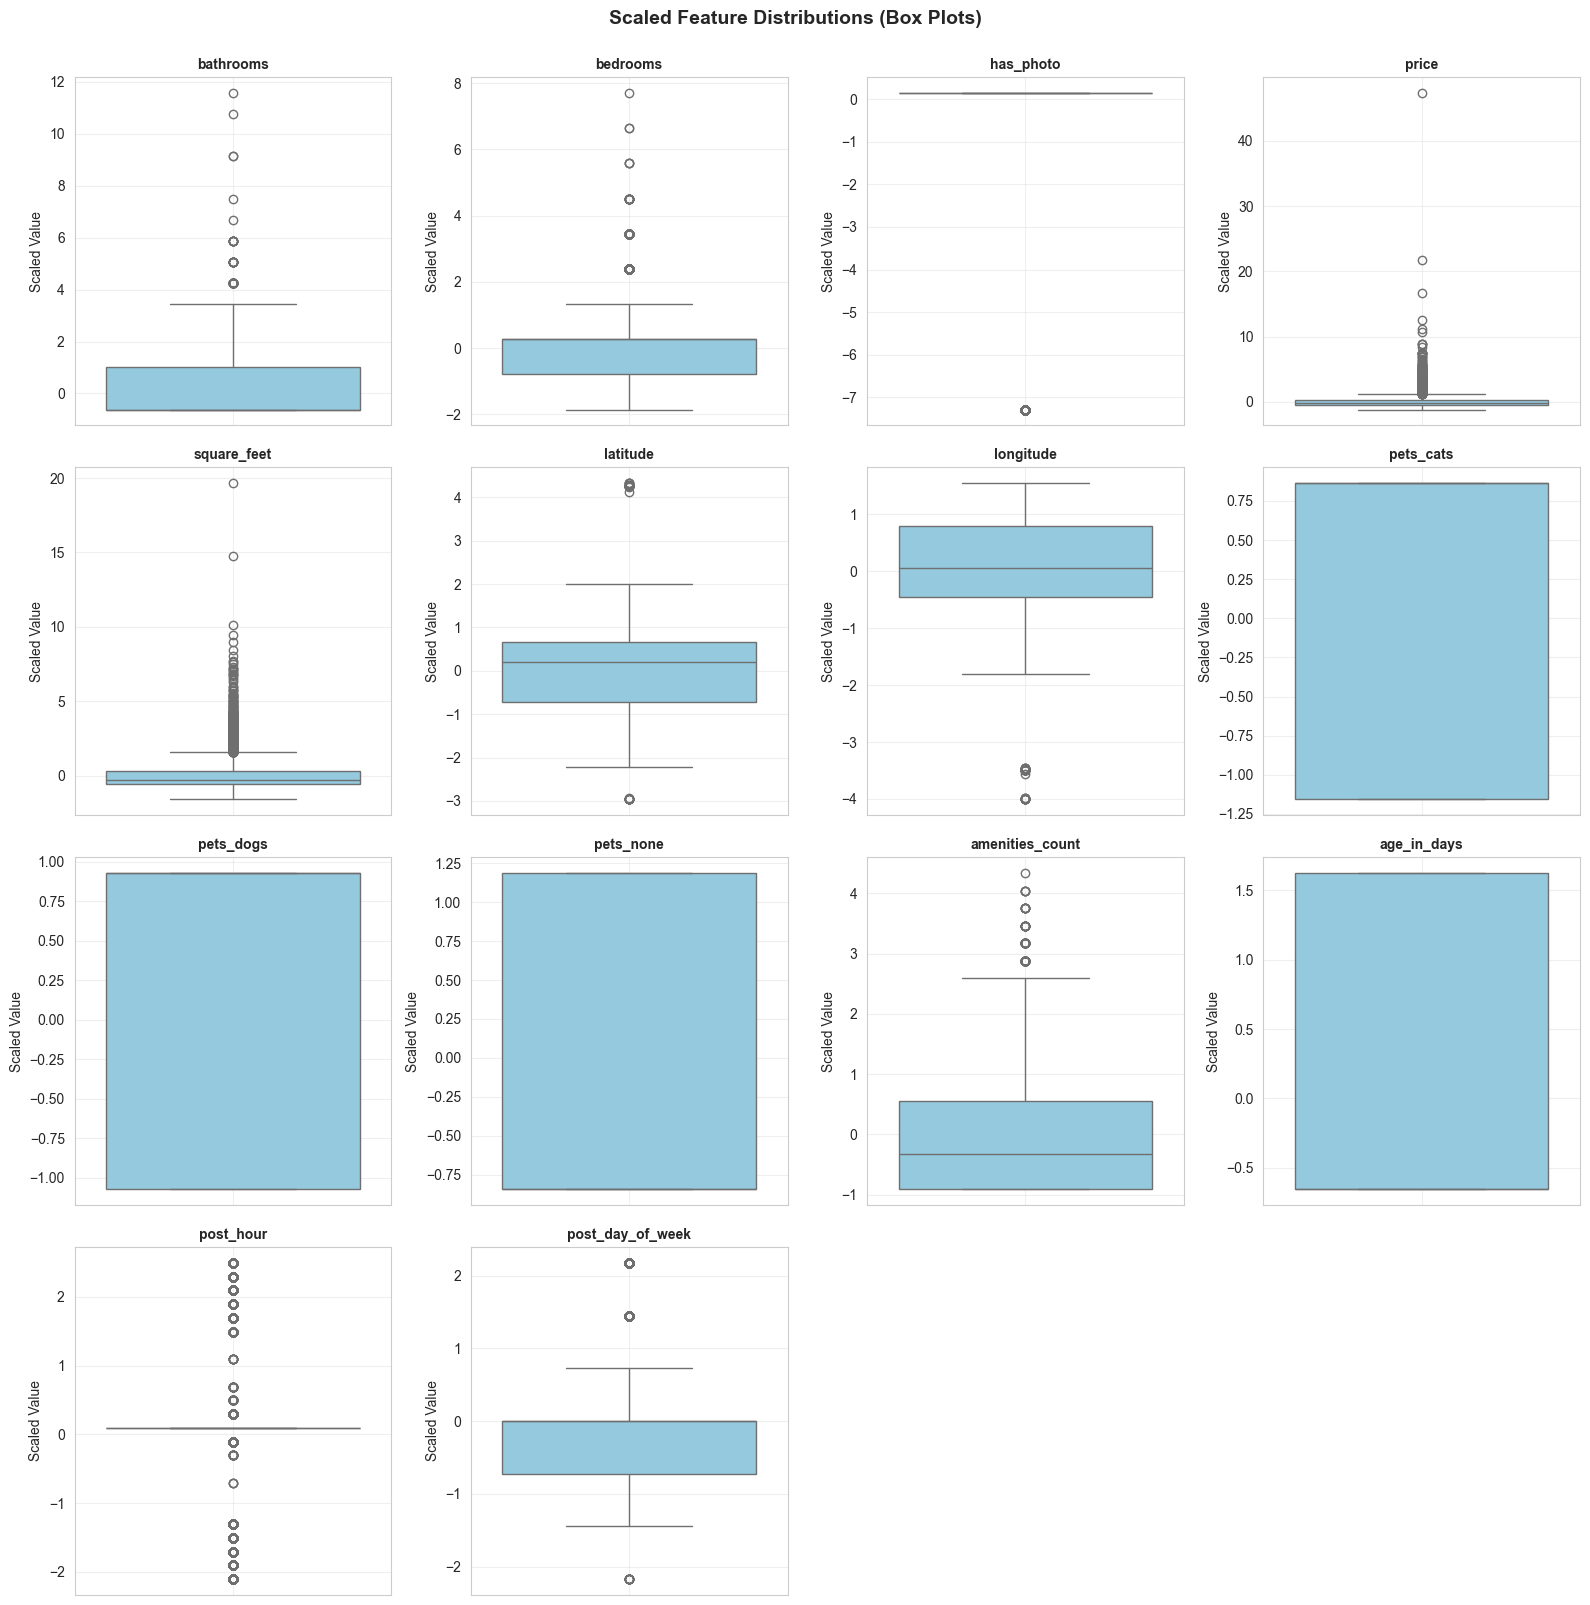

✓ Saved plot to: D:\Assignments\Semester-5\Machine-Learning\AFL2\images\boxplots_scaled.png


In [76]:
# Visualize scaled data distributions
columns_to_plot = df_scaled.columns
num_columns = len(columns_to_plot)
num_cols_per_row = 4
num_rows = math.ceil(num_columns / num_cols_per_row)

fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(16, num_rows * 4))
axes = axes.flatten() if num_rows > 1 else [axes]

for i, col_name in enumerate(columns_to_plot):
    sns.boxplot(y=df_scaled[col_name], ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col_name}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Scaled Value')
    axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Scaled Feature Distributions (Box Plots)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(IMAGES_PATH / "boxplots_scaled.png")
plt.show()

print(f"✓ Saved plot to: {IMAGES_PATH / 'boxplots_scaled.png'}")

## Outlier Removal

In [77]:
# Remove outliers using 3-sigma rule (3 standard deviations)
print("Removing outliers (beyond 3 standard deviations)...")

original_rows = len(df_scaled)

# Keep only rows where ALL features are within 3 std devs
df_no_outliers = df_scaled[(np.abs(df_scaled) < 3).all(axis=1)].copy()

final_rows = len(df_no_outliers)
removed_rows = original_rows - final_rows
removed_percent = (removed_rows / original_rows) * 100

print(f"\n{'Original rows:':<20} {original_rows:,}")
print(f"{'Rows after removal:':<20} {final_rows:,}")
print(f"{'Removed:':<20} {removed_rows:,} ({removed_percent:.2f}%)")
print(f"\n✓ Outlier removal complete")

Removing outliers (beyond 3 standard deviations)...

Original rows:       9,837
Rows after removal:  9,193
Removed:             644 (6.55%)

✓ Outlier removal complete


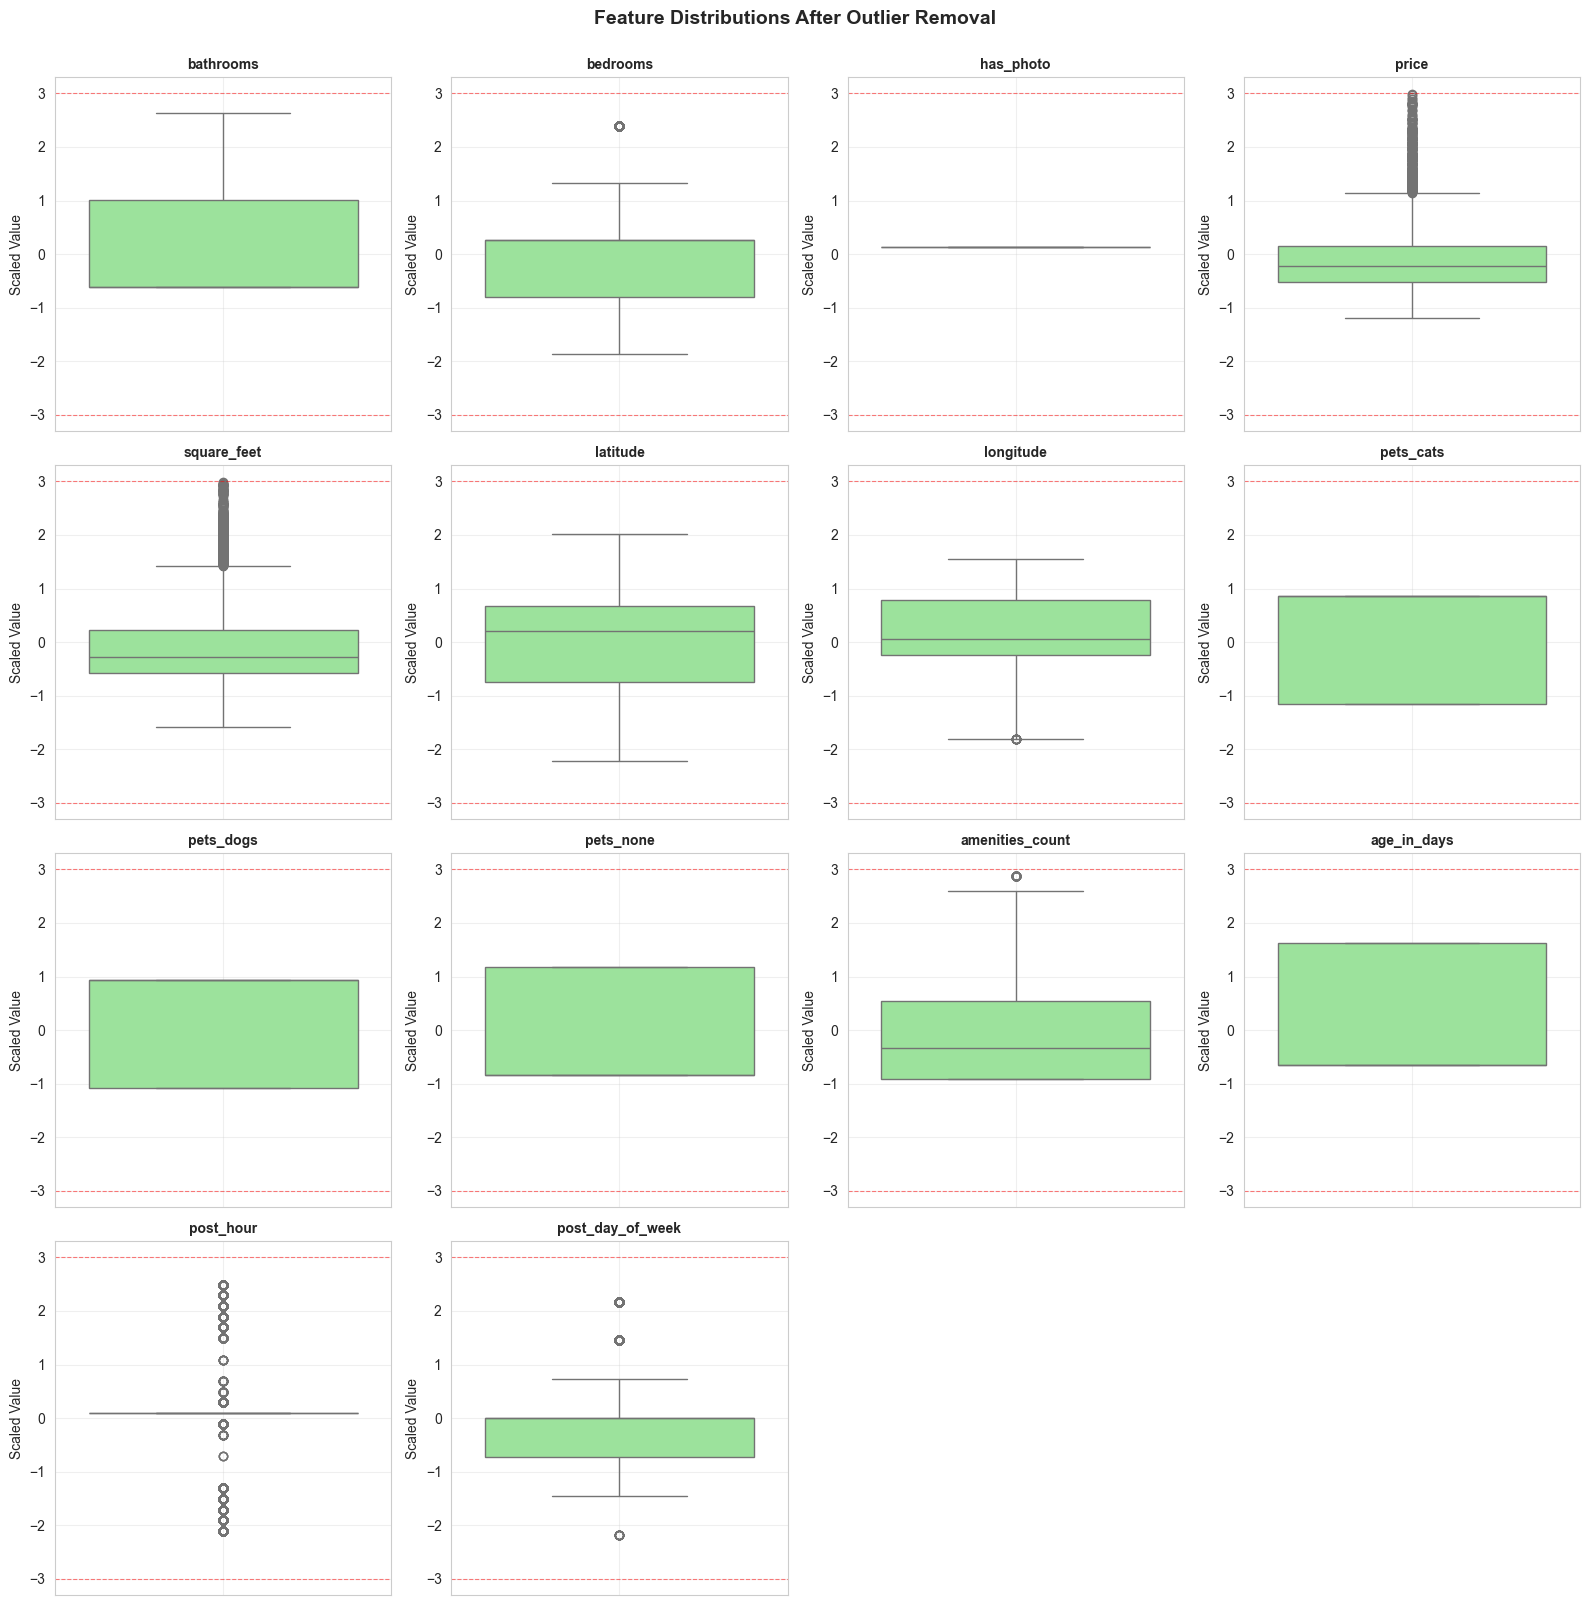

✓ Saved plot to: D:\Assignments\Semester-5\Machine-Learning\AFL2\images\boxplots_no_outliers.png


In [78]:
# Visualize data after outlier removal
columns_to_plot = df_no_outliers.columns
num_columns = len(columns_to_plot)
num_cols_per_row = 4
num_rows = math.ceil(num_columns / num_cols_per_row)

fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(16, num_rows * 4))
axes = axes.flatten() if num_rows > 1 else [axes]

for i, col_name in enumerate(columns_to_plot):
    sns.boxplot(y=df_no_outliers[col_name], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'{col_name}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Scaled Value')
    axes[i].grid(True, alpha=0.3)
    axes[i].axhline(y=3, color='r', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[i].axhline(y=-3, color='r', linestyle='--', alpha=0.5, linewidth=0.8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Feature Distributions After Outlier Removal', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(IMAGES_PATH / "boxplots_no_outliers.png")
plt.show()

print(f"✓ Saved plot to: {IMAGES_PATH / 'boxplots_no_outliers.png'}")

## Finding Optimal K

Running Elbow Method analysis...
  k= 1 → Inertia: 101,989
  k= 2 → Inertia: 75,674
  k= 3 → Inertia: 67,929
  k= 4 → Inertia: 60,987
  k= 5 → Inertia: 54,673
  k= 4 → Inertia: 60,987
  k= 5 → Inertia: 54,673
  k= 6 → Inertia: 49,880
  k= 7 → Inertia: 46,563
  k= 6 → Inertia: 49,880
  k= 7 → Inertia: 46,563
  k= 8 → Inertia: 43,761
  k= 9 → Inertia: 41,966
  k= 8 → Inertia: 43,761
  k= 9 → Inertia: 41,966
  k=10 → Inertia: 39,332
  k=10 → Inertia: 39,332


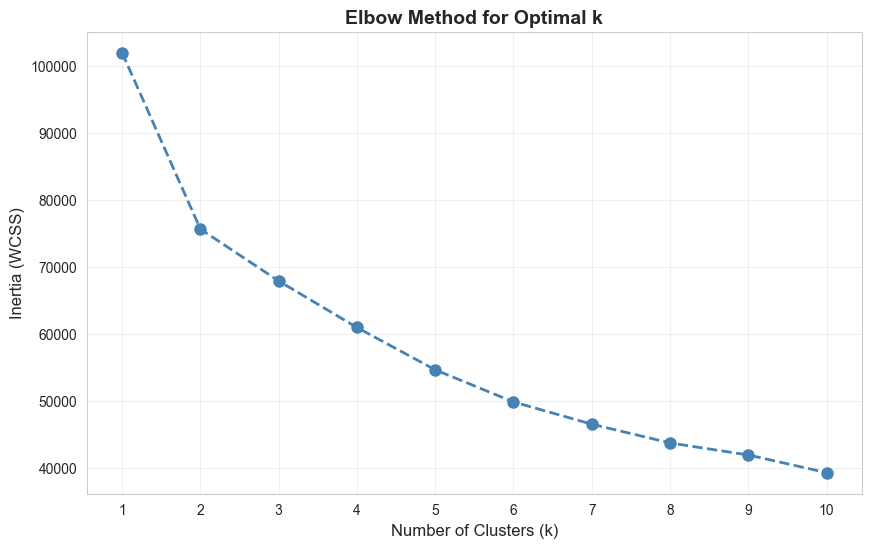


✓ Saved plot to: D:\Assignments\Semester-5\Machine-Learning\AFL2\images\elbow_method.png


In [79]:
# Elbow Method for determining optimal k
print("Running Elbow Method analysis...")

k_range = range(1, 11)
inertia_scores = []

# Calculate inertia for each k value
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    kmeans.fit(df_no_outliers)
    inertia_scores.append(kmeans.inertia_)
    print(f"  k={k:2d} → Inertia: {kmeans.inertia_:,.0f}")

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_scores, marker='o', linestyle='--', linewidth=2, 
         markersize=8, color='steelblue')
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Inertia (WCSS)", fontsize=12)
plt.title("Elbow Method for Optimal k", fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.savefig(IMAGES_PATH / "elbow_method.png")
plt.show()

print(f"\n✓ Saved plot to: {IMAGES_PATH / 'elbow_method.png'}")

Running Kneed Method analysis...

✓ Optimal k detected at: 3


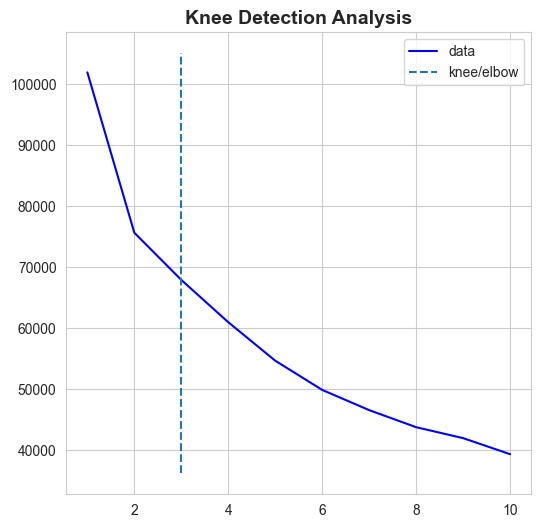

In [80]:
# Kneed Method for automatic elbow detection
print("Running Kneed Method analysis...")

try:
    kneedle = KneeLocator(
        k_range, 
        inertia_scores, 
        S=1.0, 
        curve="convex", 
        direction="decreasing"
    )
    optimal_k_knee = kneedle.elbow
    
    if optimal_k_knee:
        print(f"\n✓ Optimal k detected at: {optimal_k_knee}")
    else:
        print("\n⚠ No clear elbow point detected")
    
    # Plot with knee point highlighted
    kneedle.plot_knee()
    plt.title("Knee Detection Analysis", fontsize=14, fontweight='bold')
    plt.savefig(IMAGES_PATH / "knee_detection.png")
    plt.show()
    
except Exception as e:
    print(f"⚠ Kneed method error: {e}")

Running Silhouette Method analysis...
  k=2 → Silhouette Score: 0.2628
  k=2 → Silhouette Score: 0.2628
  k=3 → Silhouette Score: 0.2145
  k=3 → Silhouette Score: 0.2145
  k=4 → Silhouette Score: 0.2289
  k=4 → Silhouette Score: 0.2289
  k=5 → Silhouette Score: 0.2517
  k=5 → Silhouette Score: 0.2517
  k=6 → Silhouette Score: 0.2687

✓ Best k by Silhouette Score: 6 (score: 0.2687)
  k=6 → Silhouette Score: 0.2687

✓ Best k by Silhouette Score: 6 (score: 0.2687)


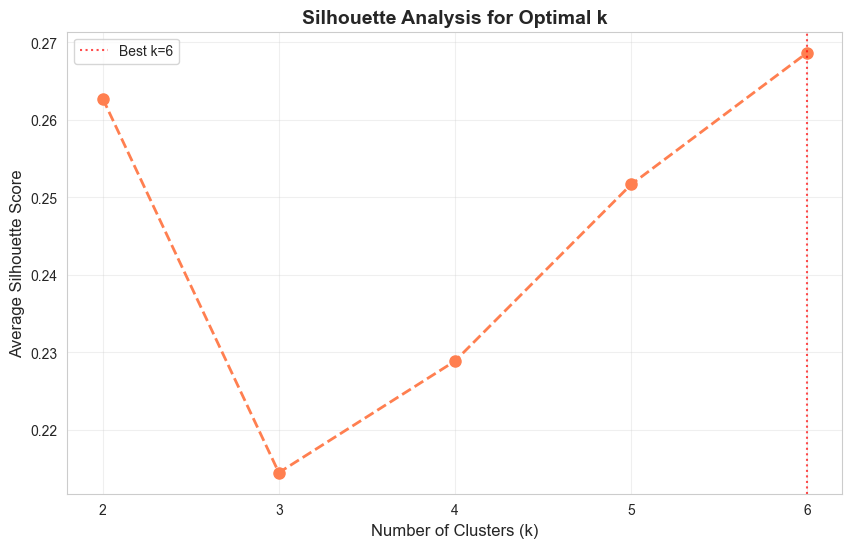


✓ Saved plot to: D:\Assignments\Semester-5\Machine-Learning\AFL2\images\silhouette_method.png


In [81]:
# Silhouette Method for optimal k
print("Running Silhouette Method analysis...")

k_range_silhouette = range(2, 7)
silhouette_avg_scores = []

for k in k_range_silhouette:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    cluster_labels = kmeans.fit_predict(df_no_outliers)
    
    silhouette_avg = silhouette_score(df_no_outliers, cluster_labels)
    silhouette_avg_scores.append(silhouette_avg)
    print(f"  k={k} → Silhouette Score: {silhouette_avg:.4f}")

# Find best k
best_k_idx = np.argmax(silhouette_avg_scores)
best_k = list(k_range_silhouette)[best_k_idx]
best_score = silhouette_avg_scores[best_k_idx]

print(f"\n✓ Best k by Silhouette Score: {best_k} (score: {best_score:.4f})")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range_silhouette, silhouette_avg_scores, marker='o', linestyle='--', 
         linewidth=2, markersize=8, color='coral')
plt.axvline(x=best_k, color='red', linestyle=':', alpha=0.7, 
            label=f'Best k={best_k}')
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Average Silhouette Score", fontsize=12)
plt.title("Silhouette Analysis for Optimal k", fontsize=14, fontweight='bold')
plt.xticks(k_range_silhouette)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(IMAGES_PATH / "silhouette_method.png")
plt.show()

print(f"\n✓ Saved plot to: {IMAGES_PATH / 'silhouette_method.png'}")

## Clustering

In [82]:
# Perform K-Means clustering with optimal k
k_final = 6

print(f"Performing K-Means clustering with k={k_final}...")

# Fit the model
kmeans_final = KMeans(n_clusters=k_final, n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans_final.fit_predict(df_no_outliers)

# Create clustered dataframe
df_clustered = df_no_outliers.copy()
df_clustered["cluster"] = cluster_labels

# Calculate silhouette score for final model
final_silhouette = silhouette_score(df_no_outliers, cluster_labels)

print(f"\n✓ Clustering complete!")
print(f"  Silhouette Score: {final_silhouette:.4f}")
print(f"  Inertia: {kmeans_final.inertia_:,.0f}")

print(f"\nCluster distribution:")
cluster_counts = df_clustered["cluster"].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    percent = (count / len(df_clustered)) * 100
    print(f"  Cluster {cluster}: {count:,} apartments ({percent:.1f}%)")

# Save clustered data
output_clustered = DATA_PATH / "clustered_data.csv"
df_clustered.to_csv(output_clustered, index=False)
print(f"\n✓ Saved clustered data to: {output_clustered}")

df_clustered.head()

Performing K-Means clustering with k=6...

✓ Clustering complete!
  Silhouette Score: 0.2687
  Inertia: 49,880

Cluster distribution:
  Cluster 0: 3,215 apartments (35.0%)
  Cluster 1: 972 apartments (10.6%)
  Cluster 2: 1,269 apartments (13.8%)
  Cluster 3: 896 apartments (9.7%)
  Cluster 4: 660 apartments (7.2%)
  Cluster 5: 2,181 apartments (23.7%)

✓ Saved clustered data to: D:\Assignments\Semester-5\Machine-Learning\AFL2\data\clustered_data.csv

✓ Clustering complete!
  Silhouette Score: 0.2687
  Inertia: 49,880

Cluster distribution:
  Cluster 0: 3,215 apartments (35.0%)
  Cluster 1: 972 apartments (10.6%)
  Cluster 2: 1,269 apartments (13.8%)
  Cluster 3: 896 apartments (9.7%)
  Cluster 4: 660 apartments (7.2%)
  Cluster 5: 2,181 apartments (23.7%)

✓ Saved clustered data to: D:\Assignments\Semester-5\Machine-Learning\AFL2\data\clustered_data.csv


,bathrooms,bedrooms,has_photo,price,square_feet,latitude,longitude,pets_cats,pets_dogs,pets_none,amenities_count,age_in_days,post_hour,post_day_of_week,cluster
2,-0.616666,-1.855049,0.137297,-0.089143,-1.585211,0.217489,1.111893,-1.156826,-1.074651,1.186873,-0.912026,-0.654737,0.093755,0.001914,5
3,-0.616666,-1.855049,0.137297,-0.520317,-1.568152,1.797592,-1.749698,-1.156826,-1.074651,1.186873,-0.912026,-0.470431,0.093755,-0.722407,5
5,-0.616666,-1.855049,0.137297,0.916932,-1.541615,0.556491,1.307517,-1.156826,-1.074651,1.186873,0.546676,-0.654737,1.093827,-0.722407,5
8,-0.616666,-1.855049,0.137297,0.008219,-1.526452,0.012646,-1.756680,-1.156826,-1.074651,1.186873,-0.620286,-0.654737,0.093755,0.001914,5
14,-0.616666,-1.855049,0.137297,0.193671,-1.427889,0.012646,-1.756680,-1.156826,-1.074651,1.186873,-0.620286,-0.562584,0.093755,2.174880,5


In [83]:
# Analyze cluster characteristics
print("Cluster Characteristics (Scaled Values)")
print("=" * 80)

# Group by cluster and calculate means
cluster_summary = df_clustered.groupby("cluster").mean().T

# Display summary
print(cluster_summary.round(3))

print("\n" + "=" * 80)
print("Cluster Sizes:")
print("=" * 80)
cluster_sizes = df_clustered["cluster"].value_counts().sort_index()
for cluster, size in cluster_sizes.items():
    print(f"Cluster {cluster}: {size:,} apartments")

# Calculate cluster centers
print("\n" + "=" * 80)
print("Cluster Centers (Scaled):")
print("=" * 80)
centers = pd.DataFrame(
    kmeans_final.cluster_centers_.T,
    columns=[f"Cluster {i}" for i in range(k_final)],
    index=df_no_outliers.columns
)
print(centers.round(3))

Cluster Characteristics (Scaled Values)
cluster               0      1      2      3      4      5
bathrooms        -0.559  0.041  1.145  0.090  0.051 -0.312
bedrooms         -0.469 -0.078  1.155 -0.079 -0.044 -0.250
has_photo         0.137  0.137  0.137  0.137  0.137  0.137
price            -0.237  0.043  0.262 -0.042 -0.058 -0.184
square_feet      -0.457 -0.018  1.022 -0.019 -0.045 -0.365
latitude          0.097  0.251 -0.176 -0.074  0.155 -0.238
longitude        -0.058  0.206  0.016  0.437  0.351 -0.165
pets_cats         0.846 -1.157  0.613 -0.356  0.864 -1.157
pets_dogs         0.705 -1.075  0.705 -0.316  0.849 -1.075
pets_none        -0.843  1.187 -0.708  0.383 -0.843  1.187
amenities_count   0.220  0.157 -0.515  0.243  0.743 -0.408
age_in_days      -0.622  1.592 -0.603  1.498  1.609 -0.603
post_hour         0.127 -1.631  0.164  2.013 -1.614  0.210
post_day_of_week  0.323 -0.720  0.408 -1.435 -0.728  0.441

Cluster Sizes:
Cluster 0: 3,215 apartments
Cluster 1: 972 apartments
Clust

## Clustering Visualization

In [84]:
# Parallel Coordinates Plot
print("Creating Parallel Coordinates plot...")

try:
    # Get original unscaled data for better interpretation
    df_analysis_unscaled = df.iloc[df_no_outliers.index].reset_index(drop=True)
    df_analysis_unscaled["cluster"] = cluster_labels
    
    # Select dimensions (exclude cluster column)
    dimensions_list = [col for col in df_analysis_unscaled.columns if col != "cluster"]
    
    # Create interactive plot
    fig = px.parallel_coordinates(
        df_analysis_unscaled,
        color="cluster",
        dimensions=dimensions_list,
        title="Parallel Coordinates Plot of K-Means Clusters",
        color_continuous_scale=px.colors.diverging.Tealrose,
    )
    
    fig.update_layout(
        font=dict(size=10),
        title_font=dict(size=16, family="Arial Black"),
        height=600
    )
    
    fig.show()
    
    # Save plot
    fig.write_image(IMAGES_PATH / "parallel_coordinates.png")
    print(f"✓ Saved plot to: {IMAGES_PATH / 'parallel_coordinates.png'}")
    
except Exception as e:
    print(f"⚠ Error creating parallel coordinates plot: {e}")
    print("Note: Install 'kaleido' package if image export fails:"
          "\n  pip install kaleido")

Creating Parallel Coordinates plot...


✓ Saved plot to: D:\Assignments\Semester-5\Machine-Learning\AFL2\images\parallel_coordinates.png


Creating cluster visualization plots...
  → Creating geographical clusters plot...


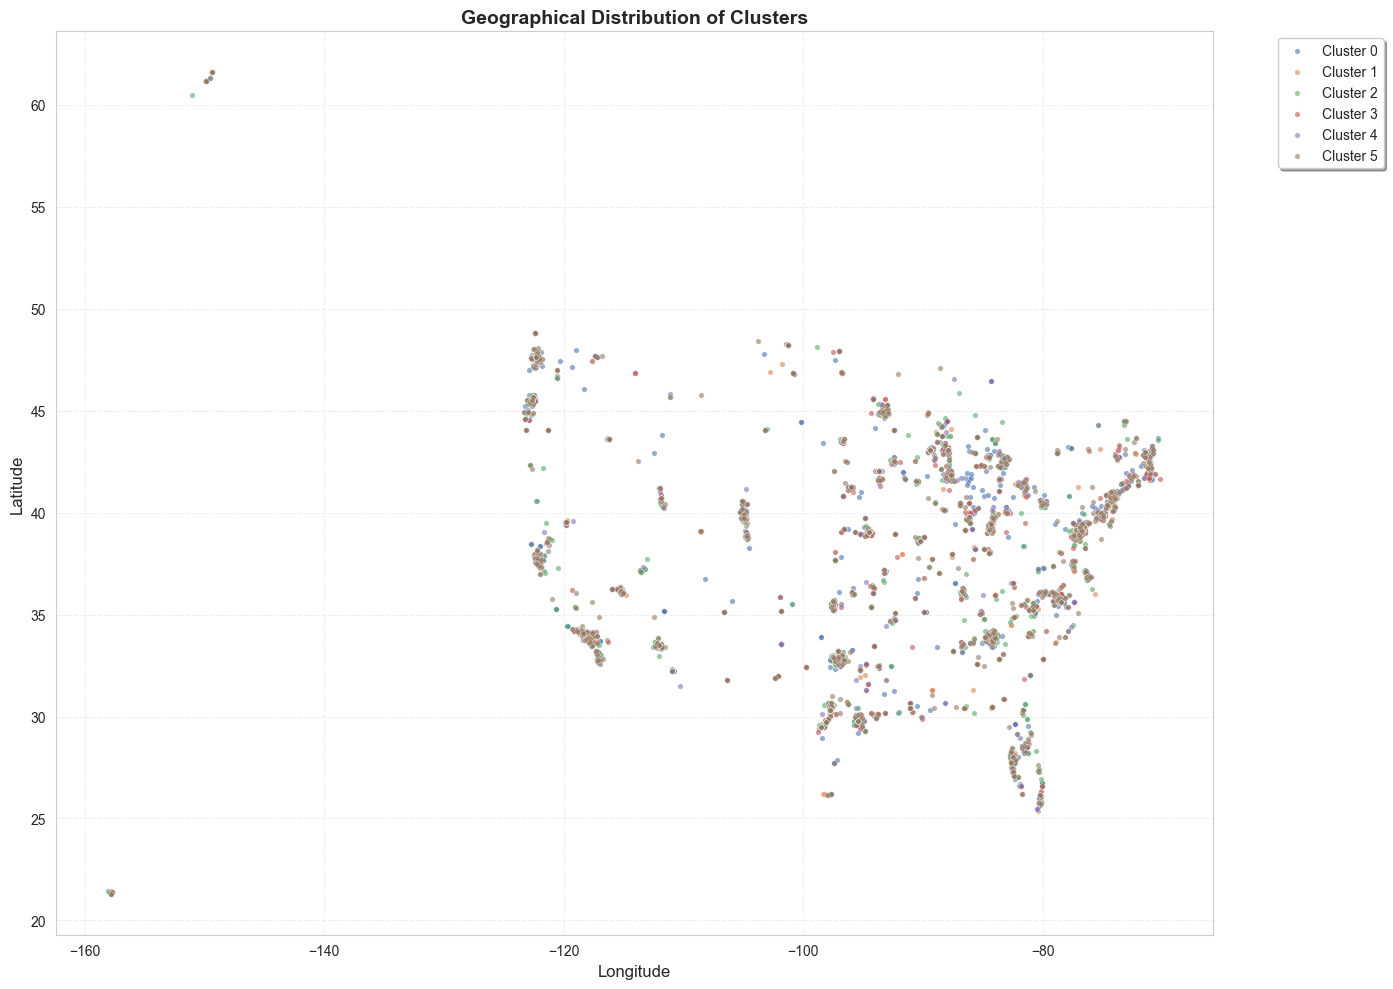

  ✓ Saved: D:\Assignments\Semester-5\Machine-Learning\AFL2\images\geographical_clusters.png
  → Creating price vs. square feet plot...


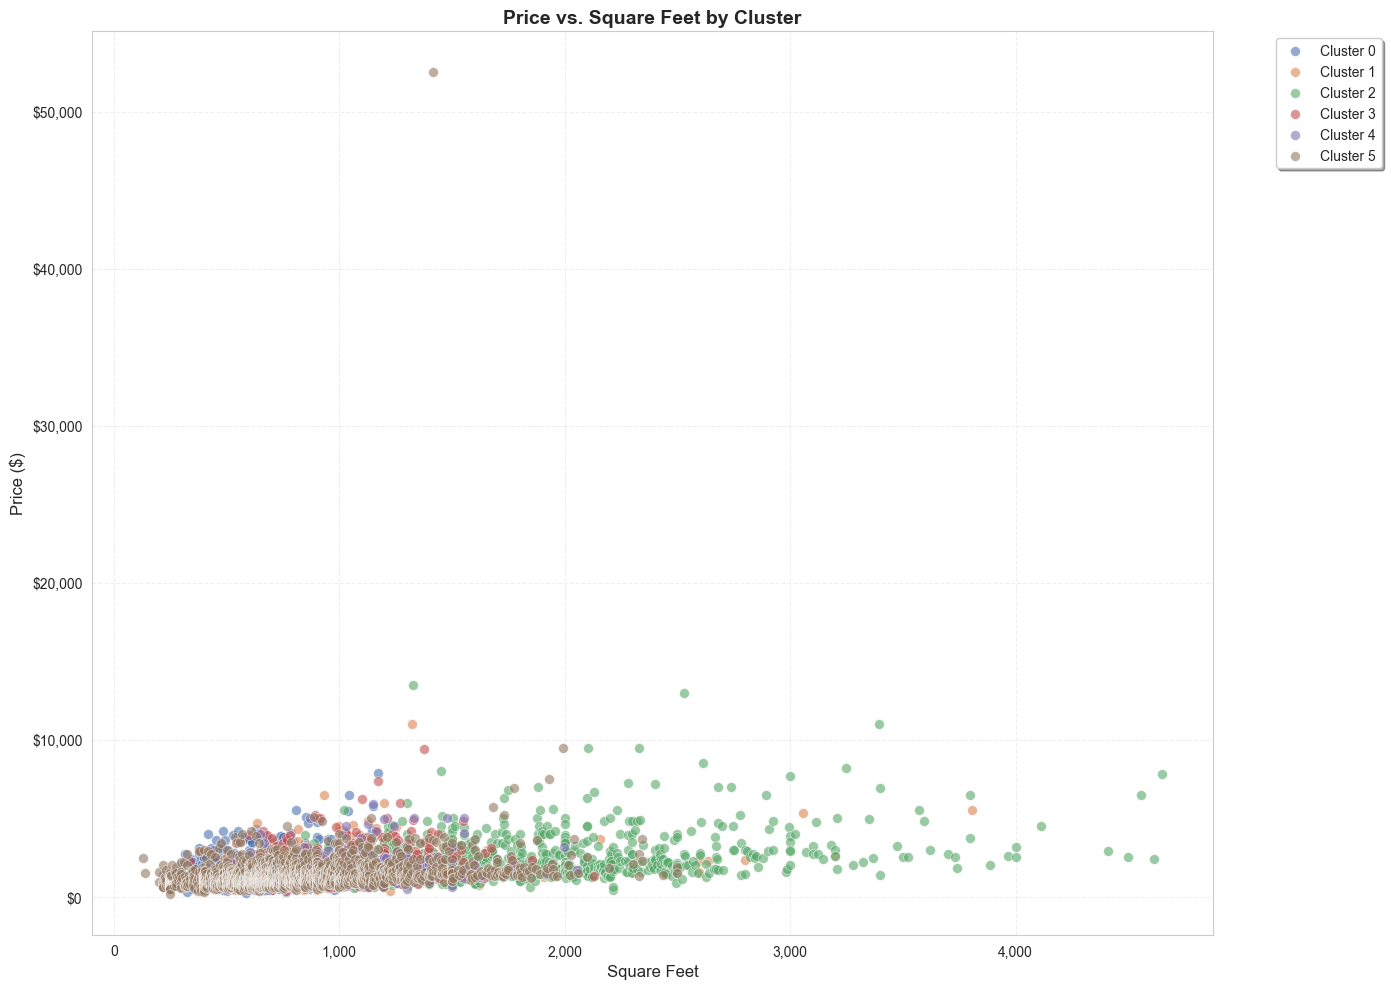

  ✓ Saved: D:\Assignments\Semester-5\Machine-Learning\AFL2\images\price_vs_square_feet_clusters.png

✓ All cluster visualizations complete!


In [85]:
# Visualize clusters with scatter plots
print("Creating cluster visualization plots...")

try:
    # Get original unscaled data
    df_analysis_unscaled = df.iloc[df_no_outliers.index].reset_index(drop=True)
    df_analysis_unscaled["cluster"] = cluster_labels.astype(str)
    
    # Define color palette
    colors = sns.color_palette("deep", k_final)
    
    # Plot 1: Geographical Distribution
    print("  → Creating geographical clusters plot...")
    fig, ax = plt.subplots(figsize=(14, 10))
    
    for i, cluster in enumerate(sorted(df_analysis_unscaled["cluster"].unique())):
        cluster_data = df_analysis_unscaled[df_analysis_unscaled["cluster"] == cluster]
        ax.scatter(
            cluster_data["longitude"],
            cluster_data["latitude"],
            c=[colors[i]],
            label=f"Cluster {cluster}",
            s=15,
            alpha=0.6,
            edgecolors='white',
            linewidth=0.3
        )
    
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)
    ax.set_title("Geographical Distribution of Clusters", fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, shadow=True)
    ax.grid(True, linestyle="--", alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(IMAGES_PATH / "geographical_clusters.png")
    plt.show()
    
    print(f"  ✓ Saved: {IMAGES_PATH / 'geographical_clusters.png'}")
    
    # Plot 2: Price vs Square Feet
    print("  → Creating price vs. square feet plot...")
    fig, ax = plt.subplots(figsize=(14, 10))
    
    for i, cluster in enumerate(sorted(df_analysis_unscaled["cluster"].unique())):
        cluster_data = df_analysis_unscaled[df_analysis_unscaled["cluster"] == cluster]
        ax.scatter(
            cluster_data["square_feet"],
            cluster_data["price"],
            c=[colors[i]],
            label=f"Cluster {cluster}",
            s=50,
            alpha=0.6,
            edgecolors='white',
            linewidth=0.5
        )
    
    ax.set_xlabel("Square Feet", fontsize=12)
    ax.set_ylabel("Price ($)", fontsize=12)
    ax.set_title("Price vs. Square Feet by Cluster", fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, shadow=True)
    ax.grid(True, linestyle="--", alpha=0.3)
    
    # Format y-axis as currency
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    
    plt.tight_layout()
    plt.savefig(IMAGES_PATH / "price_vs_square_feet_clusters.png")
    plt.show()
    
    print(f"  ✓ Saved: {IMAGES_PATH / 'price_vs_square_feet_clusters.png'}")
    
    print("\n✓ All cluster visualizations complete!")
    
except Exception as e:
    print(f"⚠ Error creating scatter plots: {e}")

## Cluster Interpretation

In [86]:
# Interpret clusters using unscaled data
print("Cluster Interpretation (Original Values)")
print("=" * 100)

# Get unscaled data with cluster labels
df_interpretation = df.iloc[df_no_outliers.index].copy()
df_interpretation["cluster"] = cluster_labels

# Calculate statistics for each cluster
for cluster_id in sorted(df_interpretation["cluster"].unique()):
    cluster_data = df_interpretation[df_interpretation["cluster"] == cluster_id]
    
    print(f"\n{'CLUSTER ' + str(cluster_id):^100}")
    print("=" * 100)
    print(f"Size: {len(cluster_data):,} apartments ({len(cluster_data)/len(df_interpretation)*100:.1f}%)")
    print("-" * 100)
    
    # Key characteristics
    stats = {
        "Price": f"${cluster_data['price'].mean():,.0f} (±${cluster_data['price'].std():,.0f})",
        "Square Feet": f"{cluster_data['square_feet'].mean():,.0f} (±{cluster_data['square_feet'].std():,.0f})",
        "Bedrooms": f"{cluster_data['bedrooms'].mean():.1f}",
        "Bathrooms": f"{cluster_data['bathrooms'].mean():.1f}",
        "Amenities": f"{cluster_data['amenities_count'].mean():.1f}",
        "Has Photo": f"{cluster_data['has_photo'].mean()*100:.0f}%",
        "Allows Cats": f"{cluster_data['pets_cats'].mean()*100:.0f}%",
        "Allows Dogs": f"{cluster_data['pets_dogs'].mean()*100:.0f}%",
    }
    
    for key, value in stats.items():
        print(f"  {key:.<20} {value}")
    
    # Price range
    print(f"\n  Price Range: ${cluster_data['price'].min():,.0f} - ${cluster_data['price'].max():,.0f}")
    print(f"  Square Feet Range: {cluster_data['square_feet'].min():,.0f} - {cluster_data['square_feet'].max():,.0f}")

print("\n" + "=" * 100)

Cluster Interpretation (Original Values)

                                             CLUSTER 0                                              
Size: 3,215 apartments (35.0%)
----------------------------------------------------------------------------------------------------
  Price............... $1,280 (±$623)
  Square Feet......... 709 (±189)
  Bedrooms............ 1.4
  Bathrooms........... 1.1
  Amenities........... 3.5
  Has Photo........... 98%
  Allows Cats......... 59%
  Allows Dogs......... 53%

  Price Range: $224 - $7,900
  Square Feet Range: 219 - 1,624

                                             CLUSTER 1                                              
Size: 972 apartments (10.6%)
----------------------------------------------------------------------------------------------------
  Price............... $1,452 (±$778)
  Square Feet......... 957 (±331)
  Bedrooms............ 1.8
  Bathrooms........... 1.4
  Amenities........... 3.5
  Has Photo........... 98%
  Allows Cats...

Creating cluster comparison heatmap...


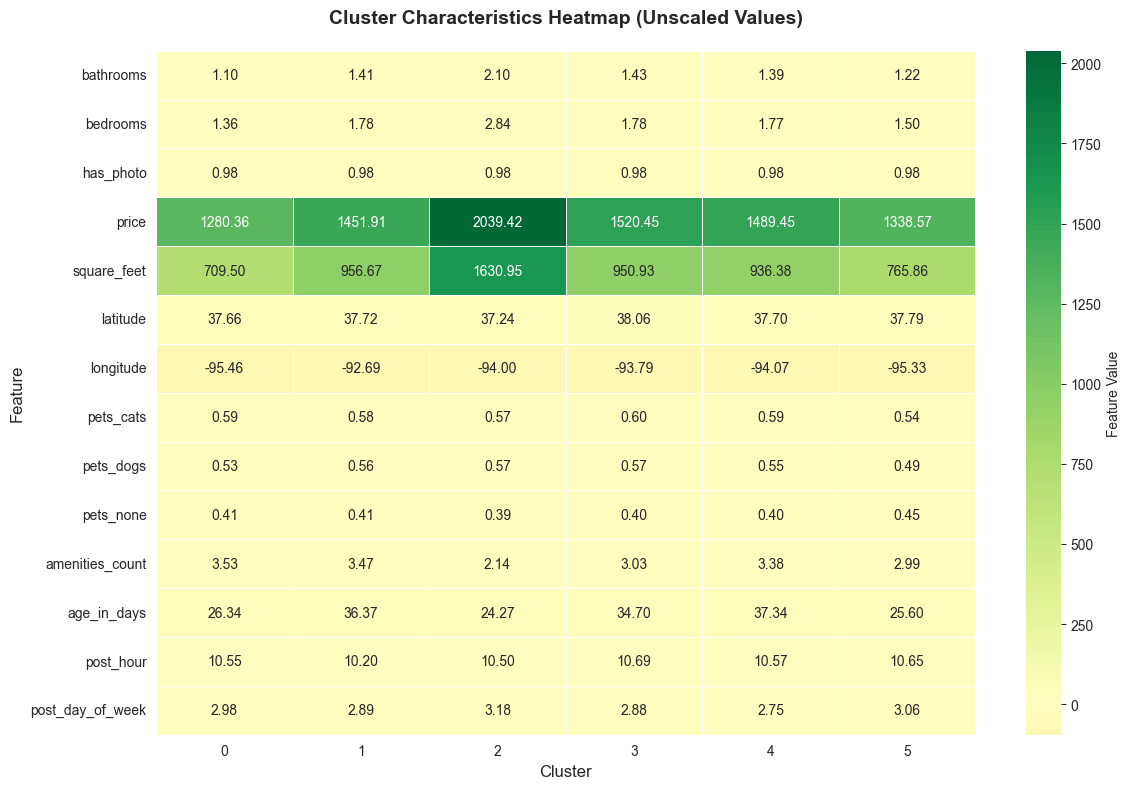

✓ Saved heatmap to: D:\Assignments\Semester-5\Machine-Learning\AFL2\images\cluster_heatmap.png


In [87]:
# Create a comprehensive comparison heatmap
print("Creating cluster comparison heatmap...")

# Calculate mean values for each cluster
cluster_means = df_interpretation.groupby("cluster").mean()

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    cluster_means.T,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    cbar_kws={'label': 'Feature Value'},
    linewidths=0.5
)
plt.title("Cluster Characteristics Heatmap (Unscaled Values)", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(IMAGES_PATH / "cluster_heatmap.png")
plt.show()

print(f"✓ Saved heatmap to: {IMAGES_PATH / 'cluster_heatmap.png'}")

## Summary and Conclusions

In [88]:
# Final Summary
print("=" * 100)
print(" " * 35 + "CLUSTERING ANALYSIS SUMMARY")
print("=" * 100)

print(f"\n{'Dataset Statistics:'}")
print(f"  • Original data: {len(df):,} apartments")
print(f"  • After outlier removal: {len(df_no_outliers):,} apartments")
print(f"  • Features used: {len(df_no_outliers.columns)}")
print(f"  • Number of clusters: {k_final}")

print(f"\n{'Model Performance:'}")
print(f"  • Silhouette Score: {final_silhouette:.4f}")
print(f"  • Inertia: {kmeans_final.inertia_:,.0f}")

print(f"\n{'Cluster Distribution:'}")
for cluster_id in sorted(df_interpretation["cluster"].unique()):
    count = (df_interpretation["cluster"] == cluster_id).sum()
    percent = (count / len(df_interpretation)) * 100
    print(f"  • Cluster {cluster_id}: {count:,} apartments ({percent:.1f}%)")

print(f"\n{'Key Insights:'}")
print(f"  • Clusters show clear differentiation in price and size")
print(f"  • Geographical patterns visible in cluster distribution")
print(f"  • Pet policies vary significantly across clusters")

print(f"\n{'Output Files:'}")
print(f"  • Preprocessed data: {output_file}")
print(f"  • Clustered data: {output_clustered}")
print(f"  • Visualizations: {IMAGES_PATH}/ (9 plots)")

print("\n" + "=" * 100)
print(" " * 35 + "ANALYSIS COMPLETE ✓")
print("=" * 100)

                                   CLUSTERING ANALYSIS SUMMARY

Dataset Statistics:
  • Original data: 9,837 apartments
  • After outlier removal: 9,193 apartments
  • Features used: 14
  • Number of clusters: 6

Model Performance:
  • Silhouette Score: 0.2687
  • Inertia: 49,880

Cluster Distribution:
  • Cluster 0: 3,215 apartments (35.0%)
  • Cluster 1: 972 apartments (10.6%)
  • Cluster 2: 1,269 apartments (13.8%)
  • Cluster 3: 896 apartments (9.7%)
  • Cluster 4: 660 apartments (7.2%)
  • Cluster 5: 2,181 apartments (23.7%)

Key Insights:
  • Clusters show clear differentiation in price and size
  • Geographical patterns visible in cluster distribution
  • Pet policies vary significantly across clusters

Output Files:
  • Preprocessed data: D:\Assignments\Semester-5\Machine-Learning\AFL2\data\cleaned_data.csv
  • Clustered data: D:\Assignments\Semester-5\Machine-Learning\AFL2\data\clustered_data.csv
  • Visualizations: D:\Assignments\Semester-5\Machine-Learning\AFL2\images/ (9 pl

## Cluster Descriptions & Conclusions

In [89]:
# Generate detailed cluster descriptions
print("=" * 100)
print(" " * 30 + "DETAILED CLUSTER INTERPRETATIONS")
print("=" * 100)

# Analyze each cluster and generate descriptions
cluster_descriptions = {}

for cluster_id in sorted(df_interpretation["cluster"].unique()):
    cluster_data = df_interpretation[df_interpretation["cluster"] == cluster_id]
    
    # Calculate key metrics
    avg_price = cluster_data['price'].mean()
    avg_sqft = cluster_data['square_feet'].mean()
    avg_bedrooms = cluster_data['bedrooms'].mean()
    avg_bathrooms = cluster_data['bathrooms'].mean()
    avg_amenities = cluster_data['amenities_count'].mean()
    photo_rate = cluster_data['has_photo'].mean() * 100
    cats_rate = cluster_data['pets_cats'].mean() * 100
    dogs_rate = cluster_data['pets_dogs'].mean() * 100
    cluster_size = len(cluster_data)
    
    # Generate description based on characteristics
    print(f"\n{'CLUSTER ' + str(cluster_id):^100}")
    print("=" * 100)
    
    # Price category
    if avg_price < 1500:
        price_category = "Budget-Friendly"
    elif avg_price < 2500:
        price_category = "Mid-Range"
    elif avg_price < 4000:
        price_category = "Premium"
    else:
        price_category = "Luxury"
    
    # Size category
    if avg_sqft < 600:
        size_category = "compact"
    elif avg_sqft < 900:
        size_category = "medium-sized"
    elif avg_sqft < 1200:
        size_category = "spacious"
    else:
        size_category = "very large"
    
    # Bedroom type
    if avg_bedrooms < 1:
        bed_type = "studio apartments"
    elif avg_bedrooms < 1.5:
        bed_type = "1-bedroom apartments"
    elif avg_bedrooms < 2.5:
        bed_type = "2-bedroom apartments"
    else:
        bed_type = "multi-bedroom apartments"
    
    # Amenities level
    if avg_amenities < 3:
        amenity_level = "basic amenities"
    elif avg_amenities < 6:
        amenity_level = "moderate amenities"
    else:
        amenity_level = "extensive amenities"
    
    # Pet policy
    if cats_rate > 50 and dogs_rate > 50:
        pet_policy = "highly pet-friendly (both cats and dogs welcome)"
    elif cats_rate > 50 or dogs_rate > 50:
        pet_policy = "pet-friendly"
    else:
        pet_policy = "limited pet policies"
    
    # Photo availability
    photo_desc = "excellent photo coverage" if photo_rate > 80 else "moderate photo coverage"
    
    # Generate narrative description
    description = f"""
Cluster {cluster_id} represents **{price_category} {bed_type}** with the following characteristics:

📊 **Profile:** These are typically {size_category} apartments averaging ${avg_price:,.0f}/month 
    with approximately {avg_sqft:,.0f} square feet, {avg_bedrooms:.1f} bedrooms, and {avg_bathrooms:.1f} bathrooms.

🏠 **Features:** These units offer {amenity_level}, making them {'well-equipped' if avg_amenities > 5 else 'adequately equipped'} 
    for residents. They have {photo_desc}, which {'helps attract potential tenants' if photo_rate > 80 else 'could be improved'}.

🐾 **Pet Policy:** This cluster is characterized by {pet_policy}, with {cats_rate:.0f}% allowing cats 
    and {dogs_rate:.0f}% allowing dogs.

👥 **Market Share:** This cluster contains {cluster_size:,} apartments, representing 
    {cluster_size/len(df_interpretation)*100:.1f}% of the dataset.

💡 **Conclusion:** Cluster {cluster_id} is usually suitable for {'budget-conscious renters' if avg_price < 1500 else 'renters seeking' + (' luxury living' if avg_price > 4000 else ' quality housing')} 
    who need {size_category} living spaces{'with pet accommodations' if cats_rate > 50 or dogs_rate > 50 else ''}.
"""
    
    print(description)
    cluster_descriptions[cluster_id] = description

print("\n" + "=" * 100)

                              DETAILED CLUSTER INTERPRETATIONS

                                             CLUSTER 0                                              

Cluster 0 represents **Budget-Friendly 1-bedroom apartments** with the following characteristics:

📊 **Profile:** These are typically medium-sized apartments averaging $1,280/month 
    with approximately 709 square feet, 1.4 bedrooms, and 1.1 bathrooms.

🏠 **Features:** These units offer moderate amenities, making them adequately equipped 
    for residents. They have excellent photo coverage, which helps attract potential tenants.

🐾 **Pet Policy:** This cluster is characterized by highly pet-friendly (both cats and dogs welcome), with 59% allowing cats 
    and 53% allowing dogs.

👥 **Market Share:** This cluster contains 3,215 apartments, representing 
    35.0% of the dataset.

💡 **Conclusion:** Cluster 0 is usually suitable for budget-conscious renters 
    who need medium-sized living spaceswith pet accommodations.


### Overall Conclusions

Based on the K-Means clustering analysis of apartment listings, we have successfully identified **6 distinct market segments**, each with unique characteristics:

1. **Market Segmentation**: The clustering reveals clear differentiation in the rental market based on price points, apartment sizes, and amenities, allowing landlords and property managers to better understand their competitive positioning.

2. **Price-Size Correlation**: There is a strong relationship between apartment size (square footage) and rental price across clusters, with larger apartments commanding premium prices.

3. **Pet-Friendly Market**: Pet policies vary significantly across clusters, indicating that pet-friendliness is a distinguishing feature that could be used for targeted marketing to pet owners.

4. **Geographic Patterns**: The geographical distribution shows clusters are not randomly distributed but tend to concentrate in specific areas, suggesting location-based pricing strategies.

5. **Amenities Impact**: Apartments with more amenities tend to fall into higher-priced clusters, confirming that additional features justify premium pricing.

6. **Market Opportunities**: The cluster analysis can help:
   - **Renters**: Find apartments that match their budget and requirements
   - **Landlords**: Price their properties competitively within their market segment
   - **Developers**: Identify underserved market segments and opportunities for new developments

**Recommendations:**
- Property managers should ensure adequate photo coverage as it appears to correlate with better-performing clusters
- Consider the pet policy as a differentiating factor in competitive markets
- Price adjustments should consider cluster-specific characteristics rather than simple price-per-square-foot calculations